<center><font size=8><b>MPG Prediction using the Auto Dataset</b></font></center>

<center><font size=5>AI Foundations - Machine Learning</font></center>


# **Problem Statement**

## **Business Context**

Fuel efficiency is an important consideration when selecting and designing automobiles. Vehicle manufacturers, consumers, and transportation analysts need to understand which vehicle characteristics are associated with better fuel economy.

The Auto dataset contains information about automobiles, including engine characteristics, vehicle weight, acceleration, model year, and country of origin. These variables can be used to understand and predict **miles per gallon (MPG)**.


## **Objective**

The objective of this study is to develop a predictive model that estimates a vehicle's **MPG (miles per gallon)** from its characteristics.

The analysis follows these steps:

1. Analyze the Auto dataset.
2. Visualize important patterns and relationships.
3. Clean and preprocess the data.
4. Build Linear Regression models with progressively more features.
5. Evaluate model performance using **MSE** and **R-squared**.
6. Compare the models and select an appropriate final model.
7. Draw practical conclusions about factors associated with fuel efficiency.


## **Data Description**

The dataset contains automobile characteristics:

- **mpg**: Miles per gallon; the target variable.
- **cylinders**: Number of engine cylinders.
- **displacement**: Engine displacement.
- **horsepower**: Engine horsepower.
- **weight**: Vehicle weight.
- **acceleration**: Time taken to reach a specified speed.
- **year**: Model year.
- **origin**: Region/country of origin represented numerically.
- **name**: Name of the automobile.

The goal is to predict **mpg** using the available automobile characteristics.


# **Installing and Importing Necessary Libraries**

Before building the model, import libraries for data manipulation, visualization, preprocessing, model building, and evaluation.

In [ ]:
# Import libraries for reading and manipulating data
import pandas as pd
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Import utilities for performance evaluation
from sklearn.metrics import mean_squared_error, r2_score

# Import utility for splitting the data
from sklearn.model_selection import train_test_split


# **Loading the Data**

With libraries in place, the next step is to load the Auto dataset.

The expected file name is **`Auto.csv`**. The file can be loaded from Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Dataset/GenAIDataset/Auto.csv')


# **Data Overview**

Before modeling, it is important to understand the structure and quality of the dataset.

We will check:

- Number of rows and columns
- First and last records
- Column names and data types
- Missing values
- Numerical and categorical summaries
- Duplicate observations


In [ ]:
data.shape


(398, 9)

In [ ]:
data.head(10)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl


In [ ]:
data.tail(10)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
388,26.0,4,156.0,92,2585,14.5,82,1,chrysler lebaron medallion
389,22.0,6,232.0,112,2835,14.7,82,1,ford granada l
390,32.0,4,144.0,96,2665,13.9,82,3,toyota celica gt
391,36.0,4,135.0,84,2370,13.0,82,1,dodge charger 2.2
392,27.0,4,151.0,90,2950,17.3,82,1,chevrolet camaro
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger
397,31.0,4,119.0,82,2720,19.4,82,1,chevy s-10


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


The `info()` output helps us identify the number of observations, data types, and possible missing values.

In [ ]:
data.isnull().sum()


,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [ ]:
data[data['horsepower'] == '?']

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
32,25.0,4,98.0,?,2046,19.0,71,1,ford pinto
126,21.0,6,200.0,?,2875,17.0,74,1,ford maverick
330,40.9,4,85.0,?,1835,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,?,2905,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,?,2320,15.8,81,2,renault 18i
374,23.0,4,151.0,?,3035,20.5,82,1,amc concord dl


### Handling Missing Values

In the Auto dataset, the **horsepower** column may contain missing values represented by `?`. therefore convert horsepower to numeric values and then check for missing values.

This step is important because Linear Regression requires numerical input without missing values.


In [ ]:
# Convert horsepower to numeric.
# Invalid values such as '?' become NaN.
data['horsepower'] = pd.to_numeric(data['horsepower'], errors='coerce')

# Check missing values again
data.isnull().sum()


,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [ ]:
data = data.dropna().copy()

print("Shape after removing missing values:", data.shape)


Shape after removing missing values: (392, 9)


In [ ]:
data.describe()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [ ]:
data.describe(include='object')


,car name
count,392
unique,301
top,amc matador
freq,5


The `name` column contains automobile names and is mainly an identifier/text field. We will not use it directly in the Linear Regression model.

In [ ]:
duplicate_rows = data[data.duplicated()]

print(f"Number of duplicate rows: {len(duplicate_rows)}")

duplicate_rows


Number of duplicate rows: 0


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name


In [ ]:
data = data.drop_duplicates().copy()

print(f"Shape after removing duplicates: {data.shape}")


Shape after removing duplicates: (392, 9)


# **Exploratory Data Analysis**

## **Univariate Analysis**

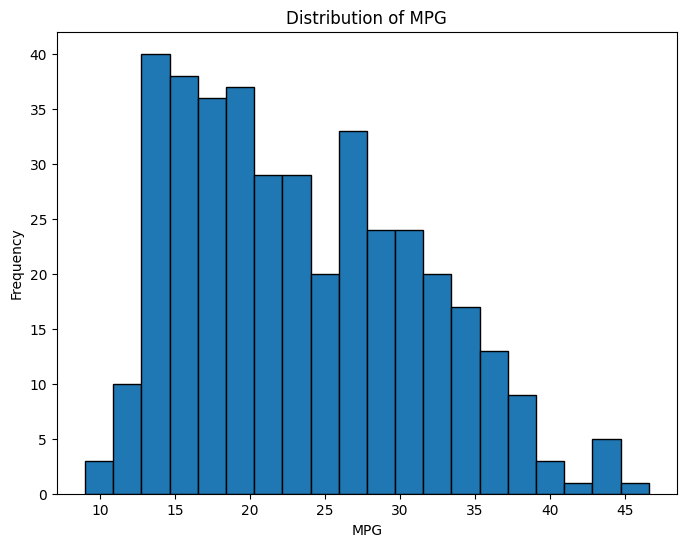

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(data['mpg'], bins=20, edgecolor='black')
plt.title('Distribution of MPG')
plt.xlabel('MPG')
plt.ylabel('Frequency')
plt.show()


The histogram helps us understand the typical MPG values and the overall shape of the distribution.

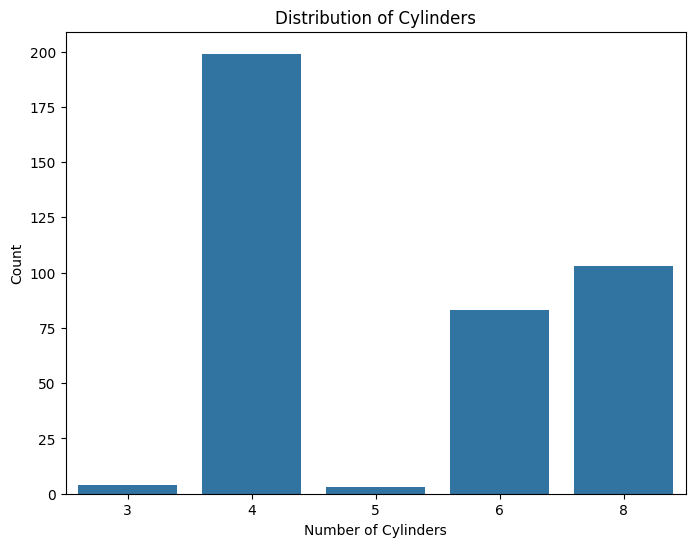

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='cylinders', data=data)
plt.title('Distribution of Cylinders')
plt.xlabel('Number of Cylinders')
plt.ylabel('Count')
plt.show()


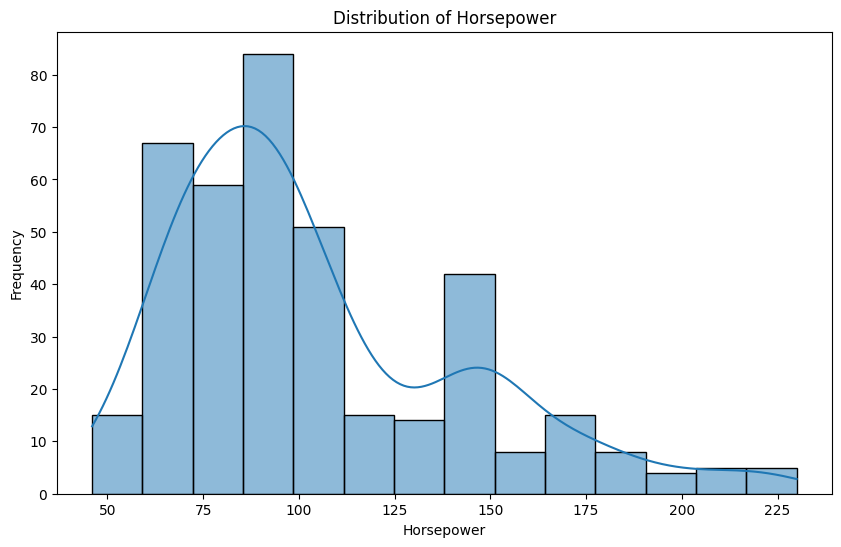

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data['horsepower'], kde=True)
plt.title('Distribution of Horsepower')
plt.xlabel('Horsepower')
plt.ylabel('Frequency')
plt.show()


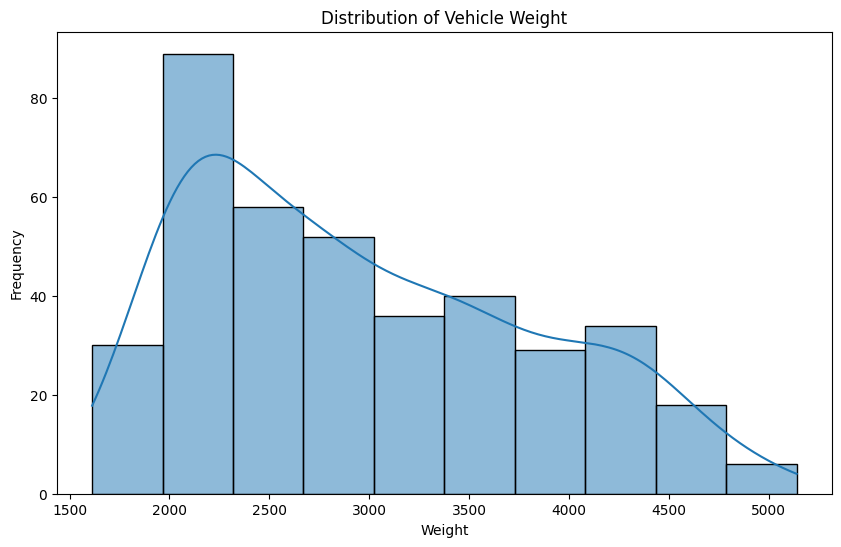

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data['weight'], kde=True)
plt.title('Distribution of Vehicle Weight')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.show()


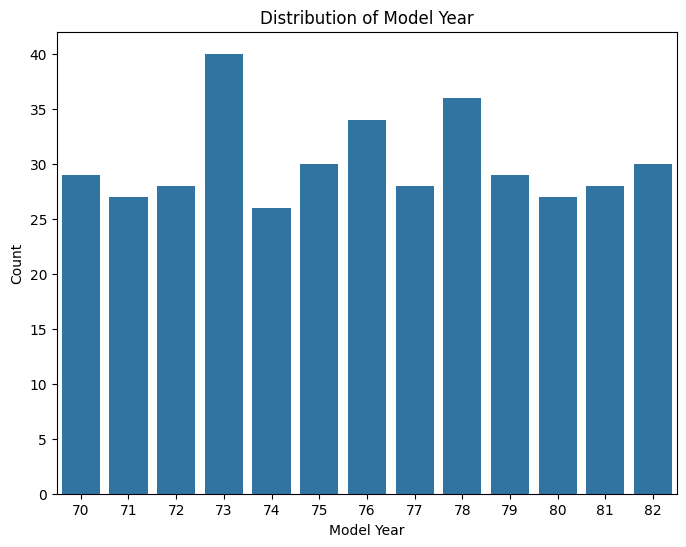

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='model year', data=data)
plt.title('Distribution of Model Year')
plt.xlabel('Model Year')
plt.ylabel('Count')
plt.show()


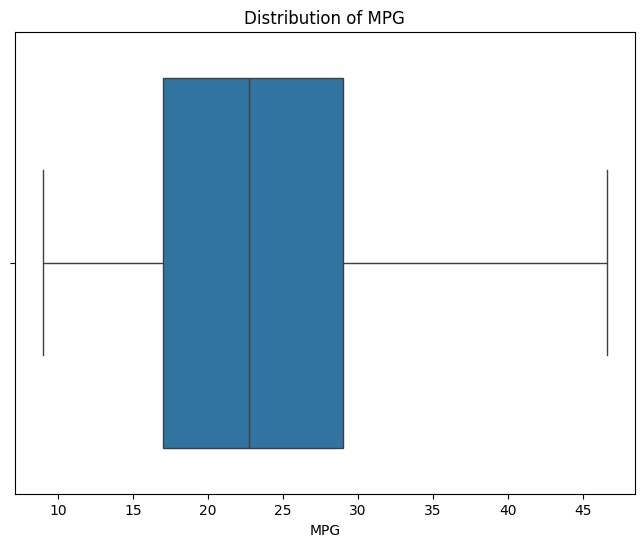

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='mpg', data=data)
plt.title('Distribution of MPG')
plt.xlabel('MPG')
plt.show()


## **Bivariate Analysis**

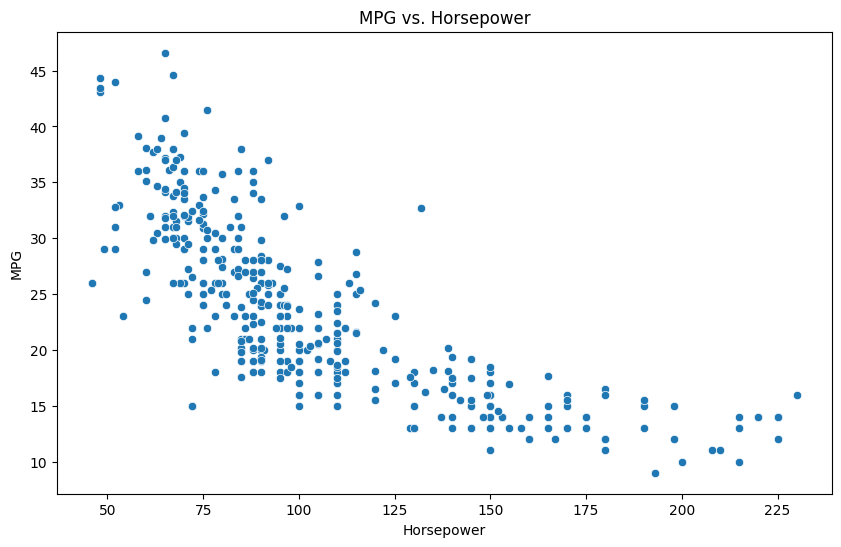

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='horsepower', y='mpg', data=data)
plt.title('MPG vs. Horsepower')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.show()


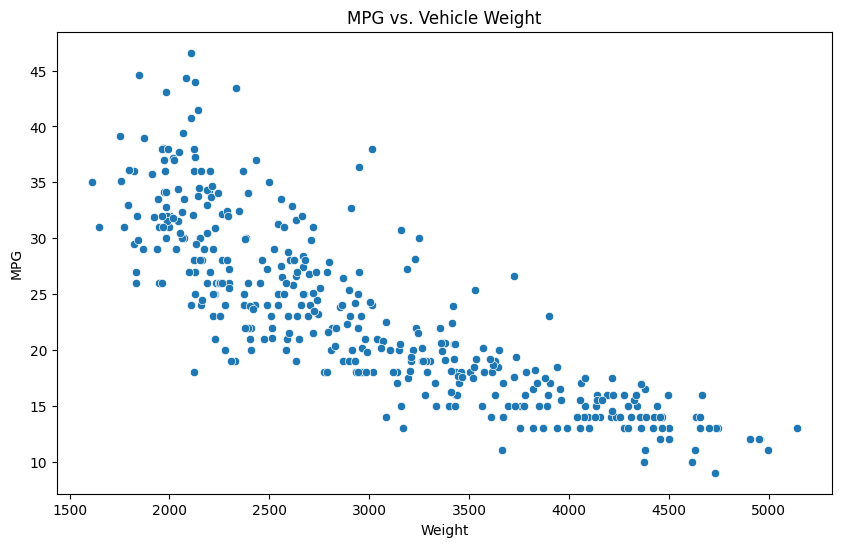

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='weight', y='mpg', data=data)
plt.title('MPG vs. Vehicle Weight')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.show()


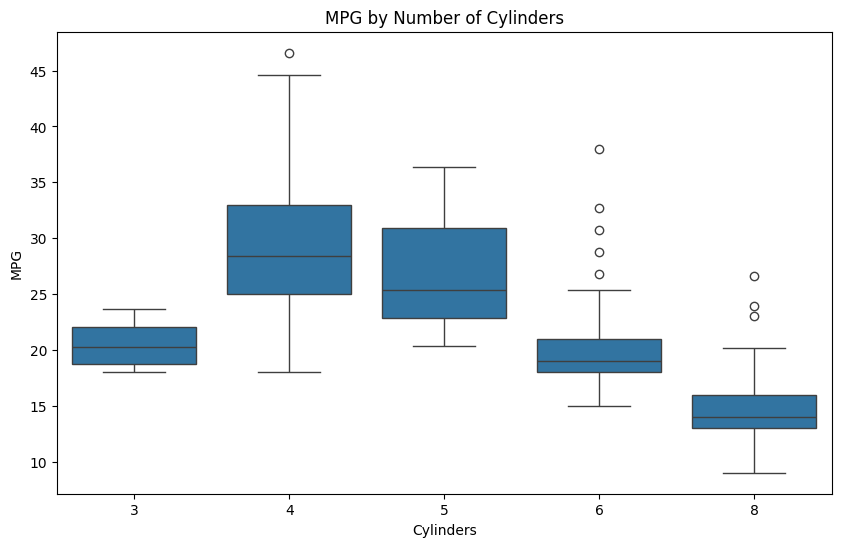

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='cylinders', y='mpg', data=data)
plt.title('MPG by Number of Cylinders')
plt.xlabel('Cylinders')
plt.ylabel('MPG')
plt.show()


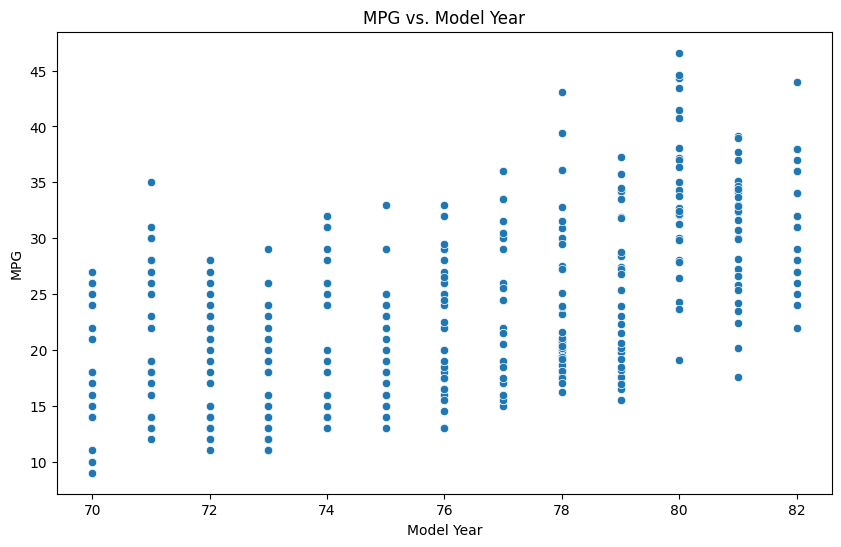

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='model year', y='mpg', data=data)
plt.title('MPG vs. Model Year')
plt.xlabel('Model Year')
plt.ylabel('MPG')
plt.show()


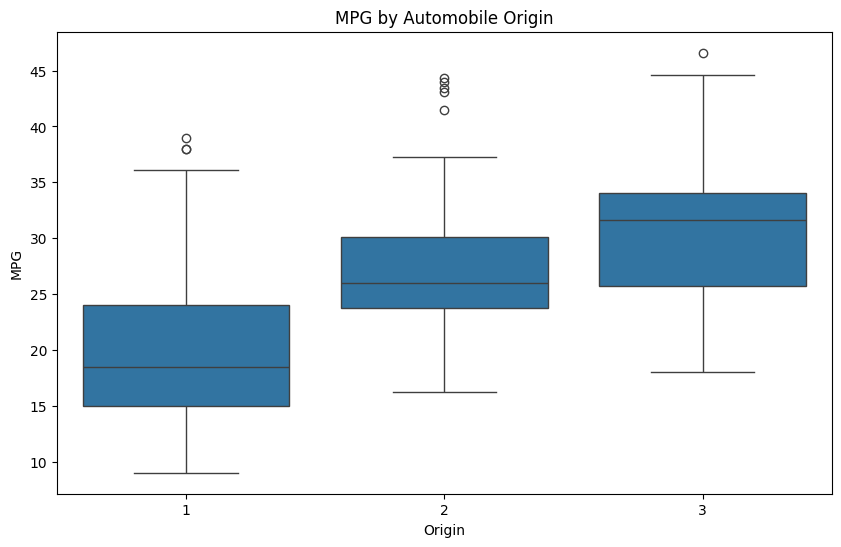

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='origin', y='mpg', data=data)
plt.title('MPG by Automobile Origin')
plt.xlabel('Origin')
plt.ylabel('MPG')
plt.show()


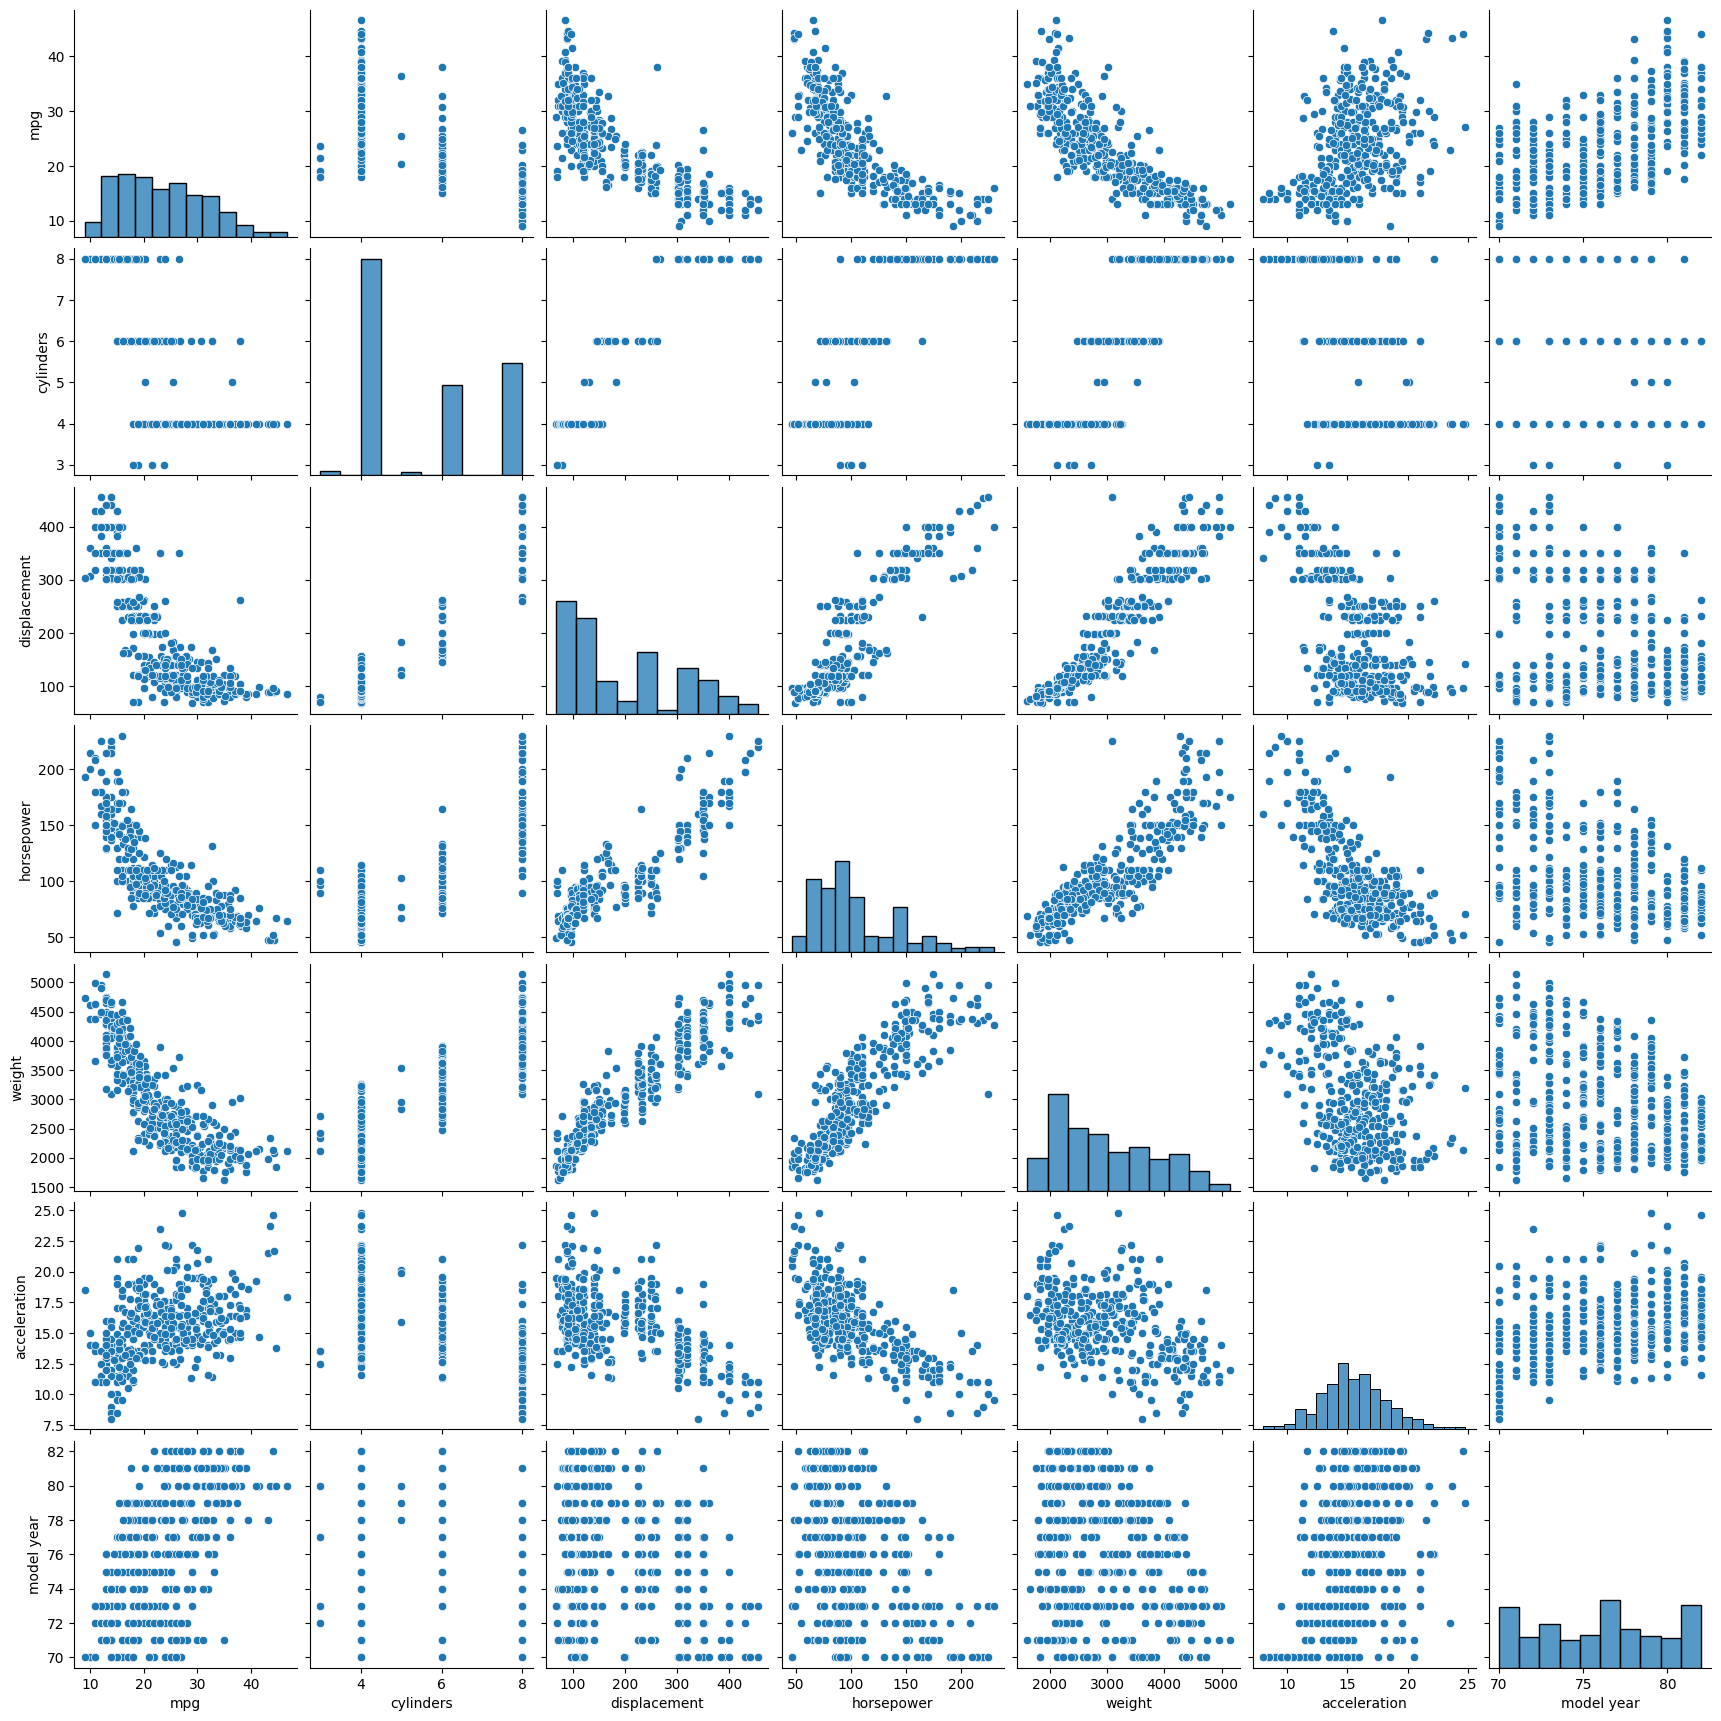

In [ ]:
pairplot_cols = [
    'mpg', 'cylinders', 'displacement',
    'horsepower', 'weight', 'acceleration', 'model year'
]

sns.pairplot(data[pairplot_cols])
plt.show()


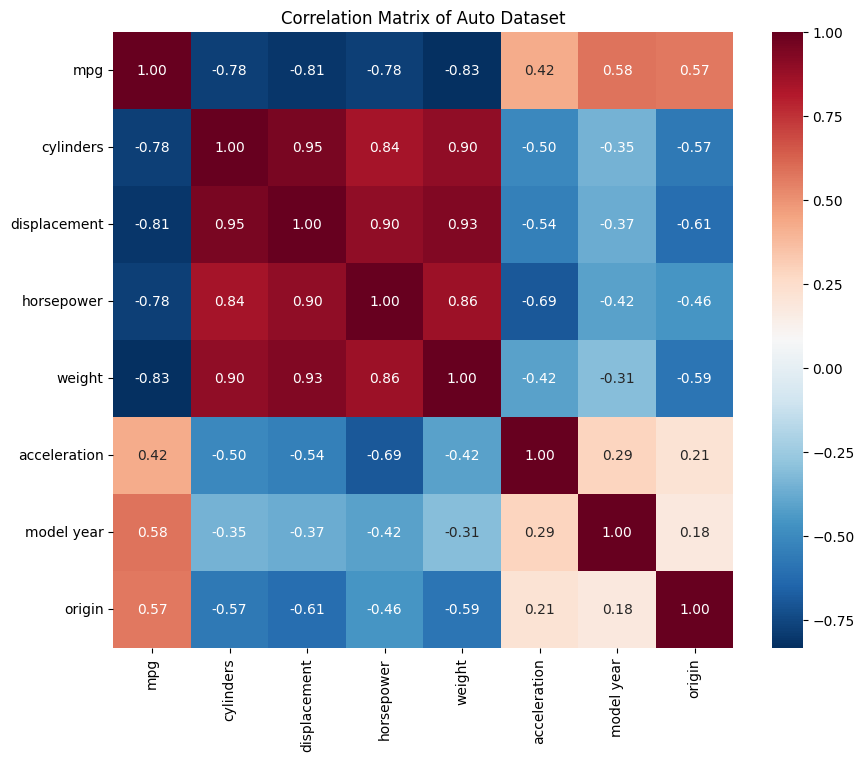

In [ ]:
numerical_cols = [
    'mpg', 'cylinders', 'displacement',
    'horsepower', 'weight', 'acceleration', 'model year', 'origin'
]

correlation_matrix = data[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='RdBu_r')
plt.title('Correlation Matrix of Auto Dataset')
plt.show()


### **Initial EDA Observations**

Typical patterns to look for include:

1. **Weight and horsepower:** Heavier and more powerful vehicles tend to have lower MPG.
2. **Cylinders:** Vehicles with more cylinders generally show lower fuel efficiency.
3. **Model year:** Newer vehicles generally tend to have higher MPG.
4. **Acceleration:** Its relationship with MPG can be explored through the scatter plot and correlation matrix.
5. **Origin:** MPG distributions can differ across automobile origins.

These are exploratory observations; the regression model will quantify the relationships using the available data.


# **Data Preprocessing**

### Prepare the Data

The `name` column is a text identifier and will not be directly used as a predictor. The remaining automobile characteristics can be used as numerical predictors.

The `origin` variable is already represented numerically in the common Auto dataset. For this introductory Linear Regression exercise, it can therefore be retained as a numerical predictor.


In [ ]:
X = data.drop(columns=['mpg', 'car name'])
y = data['mpg']

X.head()


,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,8,307.0,130.0,3504,12.0,70,1
1,8,350.0,165.0,3693,11.5,70,1
2,8,318.0,150.0,3436,11.0,70,1
3,8,304.0,150.0,3433,12.0,70,1
4,8,302.0,140.0,3449,10.5,70,1


### Train Test Split

As in the reference case study, we use **70% of the data for training and 30% for testing**.

The training data is used to learn the model, while the test data is used to evaluate how well the model performs on unseen observations.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (274, 7)
X_test shape: (118, 7)
y_train shape: (274,)
y_test shape: (118,)


# **Model Building**

## Model Evaluation Criterion

For this regression problem, use:

- **MSE (Mean Squared Error):** Measures the average squared difference between actual and predicted MPG. Lower values indicate smaller prediction errors.
- **R-squared (R²):** Indicates the proportion of variation in MPG explained by the predictors. Higher values generally indicate better explanatory performance.

Compare both training and testing performance to understand model fit and generalization.


## Model Building

In [ ]:
model_eval_results = pd.DataFrame(
    columns=['Model', 'Train_MSE', 'Train_R2', 'Test_MSE', 'Test_R2']
)


### Model 1

In [ ]:
# Define features for Model 1
X_train_m1 = X_train[['horsepower']]
X_test_m1 = X_test[['horsepower']]

# Initialize and train the Linear Regression model
model_1 = LinearRegression()
model_1.fit(X_train_m1, y_train)


LinearRegression()

In [ ]:
print(
    f'Linear Regression Equation: MPG = '
    f'{model_1.intercept_:.2f} + ({model_1.coef_[0]:.2f} * Horsepower)'
)


Linear Regression Equation: MPG = 41.08 + (-0.17 * Horsepower)


In [ ]:
y_train_pred_m1 = model_1.predict(X_train_m1)
y_test_pred_m1 = model_1.predict(X_test_m1)

train_mse_m1 = mean_squared_error(y_train, y_train_pred_m1)
train_r2_m1 = r2_score(y_train, y_train_pred_m1)

test_mse_m1 = mean_squared_error(y_test, y_test_pred_m1)
test_r2_m1 = r2_score(y_test, y_test_pred_m1)

model_eval_results.loc[len(model_eval_results)] = [
    'Model 1 (Horsepower Only)',
    train_mse_m1, train_r2_m1,
    test_mse_m1, test_r2_m1
]

model_eval_results


,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Horsepower Only),23.929911,0.62624,24.556124,0.535843


### Model 2

In [ ]:
X_train_m2 = X_train[['horsepower', 'weight']]
X_test_m2 = X_test[['horsepower', 'weight']]

model_2 = LinearRegression()
model_2.fit(X_train_m2, y_train)


LinearRegression()

In [ ]:
print(
    f'Linear Regression Equation: MPG = '
    f'{model_2.intercept_:.2f} + '
    f'({model_2.coef_[0]:.2f} * Horsepower) + '
    f'({model_2.coef_[1]:.2f} * Weight)'
)


Linear Regression Equation: MPG = 46.82 + (-0.06 * Horsepower) + (-0.01 * Weight)


In [ ]:
y_train_pred_m2 = model_2.predict(X_train_m2)
y_test_pred_m2 = model_2.predict(X_test_m2)

train_mse_m2 = mean_squared_error(y_train, y_train_pred_m2)
train_r2_m2 = r2_score(y_train, y_train_pred_m2)

test_mse_m2 = mean_squared_error(y_test, y_test_pred_m2)
test_r2_m2 = r2_score(y_test, y_test_pred_m2)

model_eval_results.loc[len(model_eval_results)] = [
    'Model 2 (Horsepower + Weight)',
    train_mse_m2, train_r2_m2,
    test_mse_m2, test_r2_m2
]

model_eval_results


,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Horsepower Only),23.929911,0.626240,24.556124,0.535843
1,Model 2 (Horsepower + Weight),17.883629,0.720676,18.498861,0.650337


### Model 3

In [ ]:
model_3 = LinearRegression()
model_3.fit(X_train, y_train)


LinearRegression()

In [ ]:
equation = f'MPG = {model_3.intercept_:.2f}'

for i, col in enumerate(X_train.columns):
    sign = '+' if model_3.coef_[i] >= 0 else '-'
    equation += f' {sign} ({abs(model_3.coef_[i]):.2f} * {col})'

print(f'Linear Regression Equation: {equation}')


Linear Regression Equation: MPG = -16.37 - (0.36 * cylinders) + (0.02 * displacement) - (0.03 * horsepower) - (0.01 * weight) + (0.04 * acceleration) + (0.74 * model year) + (1.67 * origin)


In [ ]:
y_train_pred_m3 = model_3.predict(X_train)
y_test_pred_m3 = model_3.predict(X_test)

train_mse_m3 = mean_squared_error(y_train, y_train_pred_m3)
train_r2_m3 = r2_score(y_train, y_train_pred_m3)

test_mse_m3 = mean_squared_error(y_test, y_test_pred_m3)
test_r2_m3 = r2_score(y_test, y_test_pred_m3)

model_eval_results.loc[len(model_eval_results)] = [
    'Model 3 (All Features)',
    train_mse_m3, train_r2_m3,
    test_mse_m3, test_r2_m3
]

model_eval_results


,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Horsepower Only),23.929911,0.626240,24.556124,0.535843
1,Model 2 (Horsepower + Weight),17.883629,0.720676,18.498861,0.650337
2,Model 3 (All Features),11.389522,0.822108,10.065878,0.809736


## Model Comparison and Final Model Selection

In [ ]:
model_eval_results


,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Horsepower Only),23.929911,0.626240,24.556124,0.535843
1,Model 2 (Horsepower + Weight),17.883629,0.720676,18.498861,0.650337
2,Model 3 (All Features),11.389522,0.822108,10.065878,0.809736


### Compare the Models

When comparing the models:

- Prefer a **lower Test MSE**.
- Prefer a **higher Test R²**.
- Check whether training and testing performance are reasonably close.
- A model should not be selected only because it has excellent training performance; its performance on unseen test data is important.

The model with the strongest testing performance can be selected as the final model for this case study.


### Actual vs Predicted MPG for the Final Model

The following visualization helps us see how closely the predictions follow the actual MPG values.


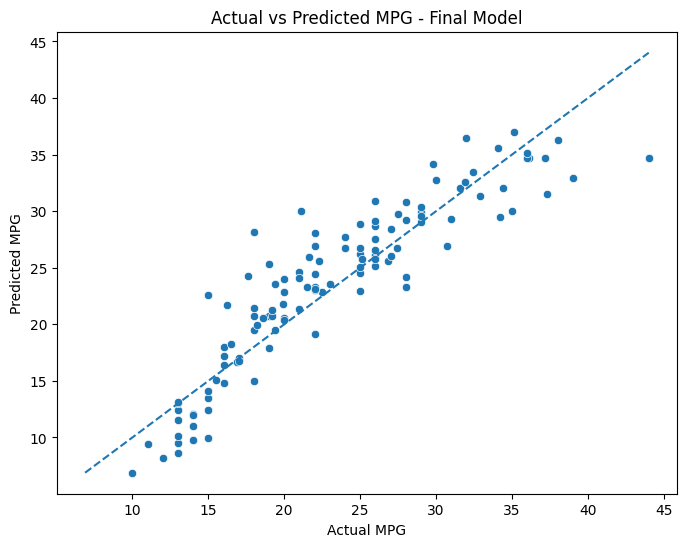

In [ ]:
# Select Model 3 as the final model for demonstration
final_model = model_3
y_test_pred = y_test_pred_m3

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_test_pred)
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Actual vs Predicted MPG - Final Model')

# Reference line: perfect predictions
min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle='--')

plt.show()


# **Business Recommendation**

Based on the exploratory analysis and regression modeling:

1. **Vehicle weight and horsepower** are important variables to consider when explaining MPG.
2. Vehicles with **higher horsepower, greater displacement, and more cylinders** generally tend to have lower fuel efficiency in this dataset.
3. **Newer model years** are generally associated with improved MPG.
4. The final regression model can be used as a baseline tool for estimating MPG from automobile characteristics.
5. Automobile manufacturers can use such analysis to understand how vehicle design characteristics relate to fuel efficiency.
6. For a production-level solution, additional techniques such as regularization, nonlinear models, cross-validation, and more detailed feature engineering could be considered.


## **Conclusion**

The Auto dataset provides a useful example of a **regression problem**, because the target variable **MPG is numerical and continuous**.

By moving from a simple one-feature model to a model containing all available numerical predictors, examine whether additional automobile characteristics improve prediction performance. The comparison of **MSE and R² on the test data** provides the basis for selecting an appropriate model.
